# Bias Analysis & Fairness Metrics 

## Table of Contents

---

### [I. Goal](#ch0)

---

### [II. Gender Bias](#ch1)

---

### [III. Age Bias](#ch2)

---

### [IV. Proxy Discrimination Analysis](#ch3)

--- 

### [V. Logistic Regression Analysis](#ch4)

---

### [VI. Interaction Effects (Gender X Age)](#ch5)

---

### [VII. Fairness Metrics](#ch6)

---

### [VIII. Conclusion](#ch7)

## Goal<a id="ch0"></a>

The goal of this analysis is to audit historical credit application decisions to identify potential bias in the loan approval process. Using statistical analysis and fairness metrics, the study examines whether approval outcomes differ across protected attributes such as gender and age, investigates whether other variables act as proxies for these attributes, and evaluates whether disparities persist after controlling for legitimate financial risk factors. The objective is to detect potential fairness issues and support governance recommendations for responsible credit decision systems.

In [1]:
##Import needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.formula.api as smf
!pip install fairlearn
from fairlearn.metrics import demographic_parity_difference

In [2]:
##Load dataset
df = pd.read_csv('/Users/miguel/Desktop/Master/T3/Data_Ecosystems/clean_credit_applications.csv')

##Small data exploration
print('Dataset size:', df.shape)
df.head()


Dataset size: (500, 34)


,application_id,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,...,spend_insurance,spend_shopping,spend_utilities,spend_entertainment,spend_rent,spend_dining,spend_gambling,spend_travel,spend_adult_entertainment,spend_alcohol
0,app_001,Stephanie Nguyen,stephanie.nguyen47@mail.com,427-90-1892,10.121.120.213,Female,1986-05-27,90230.0,102000.0,37.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,app_002,Kevin Roberts,kevin.roberts9@protonmail.com,992-61-4010,172.19.95.144,Male,1999-01-08,10020.0,41000.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,app_003,Lisa Gonzalez,lisa.gonzalez51@yahoo.com,833-33-5929,172.21.35.195,Female,1982-08-24,90213.0,65000.0,74.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,app_004,Karen Nelson,karen.nelson35@outlook.com,486-50-5539,172.31.79.76,Female,1995-02-28,90217.0,69000.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,app_005,Christine Mitchell,christine.mitchell3@outlook.com,400-91-8156,172.25.44.173,Female,1960-06-19,90296.0,39000.0,76.0,...,585.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   application_id             500 non-null    object 
 1   full_name                  500 non-null    object 
 2   email                      493 non-null    object 
 3   ssn                        496 non-null    object 
 4   ip_address                 496 non-null    object 
 5   gender                     498 non-null    object 
 6   date_of_birth              496 non-null    object 
 7   zip_code                   499 non-null    float64
 8   annual_income              500 non-null    float64
 9   credit_history_months      498 non-null    float64
 10  debt_to_income             499 non-null    float64
 11  savings_balance            499 non-null    float64
 12  loan_approved              500 non-null    bool   
 13  rejection_reason           208 non-null    object 

In [4]:
df.describe(include='all')

,application_id,full_name,email,ssn,ip_address,gender,date_of_birth,zip_code,annual_income,credit_history_months,...,spend_insurance,spend_shopping,spend_utilities,spend_entertainment,spend_rent,spend_dining,spend_gambling,spend_travel,spend_adult_entertainment,spend_alcohol
count,500,500,493,496,496,498,496,499.000000,500.000000,498.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
unique,500,475,493,494,496,2,489,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,app_001,Susan Flores,stephanie.nguyen47@mail.com,937-72-8731,10.121.120.213,Female,1988-03-18,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3,1,2,1,251,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,47735.408818,82558.865578,50.672691,...,64.046000,49.288000,75.788000,71.426000,61.780000,61.472000,6.400000,78.944000,5.912000,10.496000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39521.627144,28102.931999,31.142292,...,183.043891,161.110279,203.027928,196.526869,187.369192,180.738934,59.996927,206.771463,61.570334,76.731411
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10048.000000,63000.000000,28.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10098.000000,81000.000000,49.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90244.000000,101000.000000,72.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


## Gender Bias <a id="ch1"></a>

In [5]:
##Calculate approval rate by gender, which is the mean of the 'loan_approved' column grouped by 'gender'
approval_by_gender = (df.groupby('gender')['loan_approved'].mean())

##Combine counts and approval rates into a single DataFrame, to understand if one group is underrepesented
counts_by_gender = df['gender'].value_counts()
summary_gender = pd.DataFrame({'Total Applicants': counts_by_gender, 'Approval Rate': approval_by_gender})

summary_gender

,Total Applicants,Approval Rate
gender,,
Female,251,0.505976
Male,247,0.659919


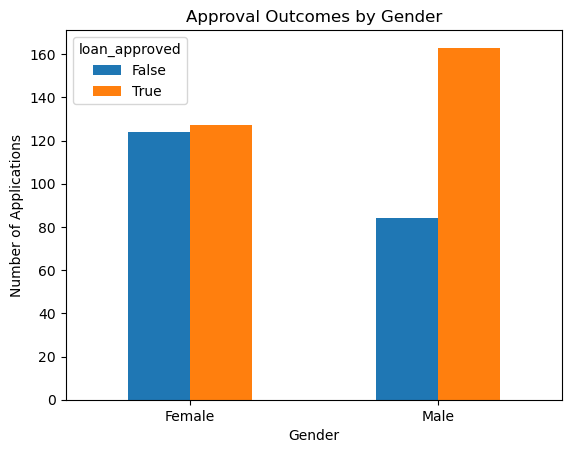

In [12]:
##Plot counts of approvals and rejections by gender
contingency = pd.crosstab(df['gender'], df['loan_approved'])

contingency.plot(kind='bar')

plt.title('Approval Outcomes by Gender')
plt.ylabel('Number of Applications')
plt.xlabel('Gender')
plt.xticks(rotation=0)

plt.show()

In [13]:
approval_female = approval_by_gender['Female']  ##Unprivileged group
approval_male = approval_by_gender['Male']      ##Privileged group

##Compute Disparate Impact (DI)
di_ratio = approval_female / approval_male

print('DI rate of:', round(di_ratio, 5))

if di_ratio < 0.8:
    print('The model has potential disparate impact against the unprivileged group.')
else:    
    print('The model has not potential disparate impact against the unprivileged group.')

DI rate of: 0.76672
The model has potential disparate impact against the unprivileged group.


**Practical impact of the approval gap**

In [14]:
##Number of female applicants
female_n = counts_by_gender['Female']

##Actual number of female approvals
female_approvals = df.loc[df['gender'] == 'Female', 'loan_approved'].sum()

##Male approval rate (already computed earlier as approval_male)
male_rate = approval_male

##Expected approvals if females had the same approval rate as males
expected_female = male_rate * female_n

##Approval shortfall
shortfall = expected_female - female_approvals

print("Female applicants:", female_n)
print("Actual female approvals:", female_approvals)
print("Expected approvals at male rate:", round(expected_female,2))
print("Approval shortfall:", round(shortfall,2))

Female applicants: 251
Actual female approvals: 127
Expected approvals at male rate: 165.64
Approval shortfall: 38.64


**Compute Chi-Square Test of Independence** for statistical evidence

_H₀_: Approval is independent of gender

_H₁_: Approval is associated with gender

In [15]:
contingency = pd.crosstab(df['gender'], df['loan_approved'])

chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print('p-value of chi-square test:', p_value)

if p_value < 0.05:
    print('Approval outcome is dependent on gender (reject H₀).')
else:
    print('No statistical evidence that approval depends on gender (fail to reject H₀).')

p-value of chi-square test: 0.0006939983289861307
Approval outcome is dependent on gender (reject H₀).


**Interpretation**

The analysis shows a clear difference in loan approval rates between genders. Female applicants have an approval rate of 50.6%, while male applicants have an approval rate of 66.0%. The Disparate Impact (DI) ratio is 0.767, which falls below the 0.8 four-fifths rule threshold, indicating potential disparate impact against female applicants.

In practical terms, with 251 female applicants, only 127 were approved, while approximately 166 approvals would be expected if women were approved at the same rate as men. This results in an approval shortfall of about 39 loans for female applicants.

The Chi-square test (p ≈ 0.00069) confirms that loan approval outcomes are statistically associated with gender. Overall, these results suggest a significant gender disparity in approval decisions, which may indicate potential bias in the decision process.

## Age Bias<a id="ch2"></a>

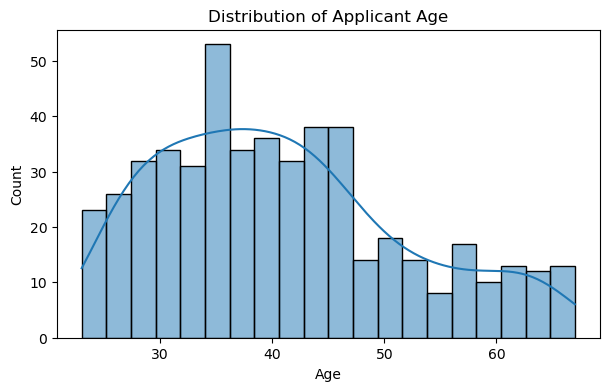

In [16]:
##Plot age distribution
plt.figure(figsize=(7,4))
sns.histplot(df["applicant_age"], bins=20, kde=True)

plt.title("Distribution of Applicant Age")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

In [17]:
##Define age bins and labels
age_bins = [0, 25, 40, 60, 100]
age_labels = ['<25', '25-40', '40-60', '60+']

##Create age_group column
df['age_group'] = pd.cut(df['applicant_age'], bins=age_bins, labels=age_labels, right=False)

##Compute the approval rate of each age group
approval_by_age = (df.groupby('age_group')['loan_approved'].mean())

##Number of applicants per age group
counts_by_age = df['age_group'].value_counts()

summary_age = pd.DataFrame({'Total Applicants': counts_by_age, 'Approval Rate': approval_by_age})

summary_age

/var/folders/ns/vvzfcfx95zsfyc2sqpjlgch40000gr/T/ipykernel_52583/488358816.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_by_age = (df.groupby('age_group')['loan_approved'].mean())


,Total Applicants,Approval Rate
age_group,,
<25,11,0.454545
25-40,241,0.518672
40-60,201,0.651741
60+,43,0.651163


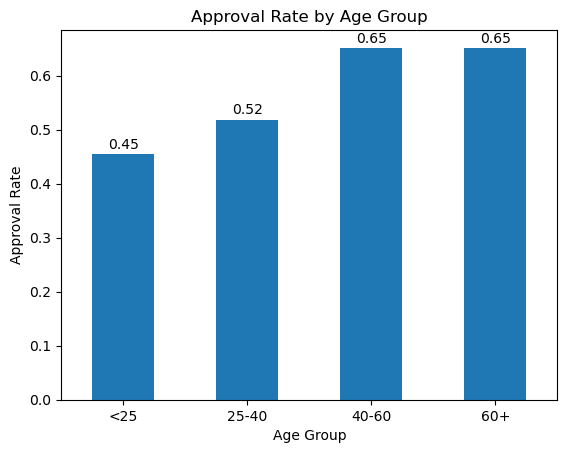

In [21]:
ax = approval_by_age.plot(kind='bar')

plt.title('Approval Rate by Age Group')
plt.ylabel('Approval Rate')
plt.xlabel('Age Group')
plt.xticks(rotation=0)

for i, v in enumerate(approval_by_age):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

**Compute Chi-Square Test of Independence** for statistical evidence

H₀: Approval is independent of age group

H₁: Approval is associated with age group

In [22]:
age_contingency = pd.crosstab(df['age_group'], df['loan_approved'])

chi2_age, p_value_age, dof_age, expected_age = stats.chi2_contingency(age_contingency)

print('p-value for age group:', p_value_age)

if p_value_age < 0.05:
    print("Statistically significant association between age group and approval (reject H₀).")
else:
    print("No statistically significant association between age group and approval (fail to reject H₀).")

p-value for age group: 0.022547498585061505
Statistically significant association between age group and approval (reject H₀).


### Experiment with bins with lower range 

In [23]:
##Determine minimum and maximum age in dataset
##We convert to integers to ensure clean bin edges

min_age = int(df['applicant_age'].min())
max_age = int(df['applicant_age'].max())

##Create bins in 5-year intervals

age_bins_5 = list(range(min_age, max_age + 5, 5))

age_bins_5[:10]  # Preview first few bins

##Create categorical age groups using pd.cut

df['age_group_5yr'] = pd.cut(df['applicant_age'], bins=age_bins_5, right=False)

##Check how many observations fall into each bin
df['age_group_5yr'].value_counts().sort_index()

age_group_5yr
[23, 28)    49
[28, 33)    85
[33, 38)    83
[38, 43)    84
[43, 48)    76
[48, 53)    35
[53, 58)    33
[58, 63)    26
[63, 68)    25
Name: count, dtype: int64

In [24]:
##Compute approval rate for each 5-year age interval

approval_by_age_5 = (df.groupby('age_group_5yr')['loan_approved'].mean())

##Count number of applicants per 5-year group
##Important to ensure bins are not too small

counts_by_age_5 = df['age_group_5yr'].value_counts().sort_index()

##Create summary table for reporting

summary_age_5 = pd.DataFrame({'Total Applicants': counts_by_age_5, 'Approval Rate': approval_by_age_5})

summary_age_5

/var/folders/ns/vvzfcfx95zsfyc2sqpjlgch40000gr/T/ipykernel_52583/3105852693.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  approval_by_age_5 = (df.groupby('age_group_5yr')['loan_approved'].mean())


,Total Applicants,Approval Rate
age_group_5yr,,
"[23, 28)",49,0.367347
"[28, 33)",85,0.494118
"[33, 38)",83,0.578313
"[38, 43)",84,0.654762
"[43, 48)",76,0.723684
"[48, 53)",35,0.628571
"[53, 58)",33,0.515152
"[58, 63)",26,0.615385
"[63, 68)",25,0.640000


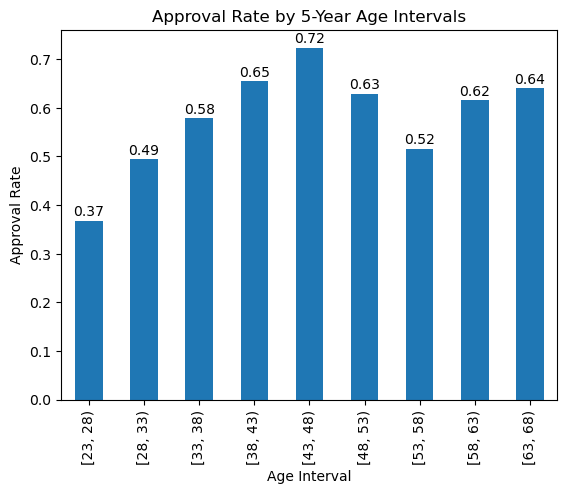

In [38]:
##Plot approval rate by age interval
ax = approval_by_age_5.plot(kind='bar')

plt.title('Approval Rate by 5-Year Age Intervals')
plt.ylabel('Approval Rate')
plt.xlabel('Age Interval')
plt.xticks(rotation=90)

for i, v in enumerate(approval_by_age_5):
    ax.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

In [39]:
##Create contingency table: rows = age interval, columns = approval outcome
age_contingency_5 = pd.crosstab(df['age_group_5yr'], df['loan_approved'])

##Perform chi-square test of independence

chi2_5, p_value_5, dof_5, expected_5 = stats.chi2_contingency(age_contingency_5)

print(f"p-value = {p_value_5:.4f}")

if p_value_5 < 0.05:
    print("Statistically significant association between age interval and approval.")
else:
    print("No statistically significant association between age interval and approval.")

p-value = 0.0060
Statistically significant association between age interval and approval.


**Interpretation**

This analysis investigates whether loan approval outcomes differ across age groups and whether the choice of age binning influences the interpretation of potential age-related bias.

Using four broad age categories (<25, 25–40, 40–60, and 60+), approval rates show a clear increasing trend with age. Applicants under 25 have the lowest approval rate (approximately 45%), while applicants aged 40 and above have noticeably higher approval rates (around 65%). This pattern suggests that younger applicants are approved less frequently than middle-aged and older applicants.

A Chi-square test of independence was conducted at a 95% confidence level (α = 0.05) to assess whether approval outcomes are statistically associated with age group. The resulting p-value is below 0.05, allowing us to reject the null hypothesis of independence. This indicates that loan approval outcomes are statistically associated with age when age is grouped into these broader categories.

To examine whether this pattern is sensitive to the way age is grouped, the analysis was repeated using finer 5-year age intervals. The more granular grouping reveals additional variation within the broader age categories, showing a gradual increase in approval rates through early and middle adulthood, peaking around the 43–48 age interval (approximately 72%), followed by moderate fluctuations in later age ranges. Despite this increased detail, the Chi-square test remains statistically significant (p = 0.006), indicating that the association between age and loan approval outcomes persists even when age is divided into smaller intervals.

Comparing the two approaches highlights an important methodological consideration: broader bins simplify the pattern and emphasize the general trend that approval rates increase with age, while finer bins reveal more nuanced variation within age ranges. However, both binning strategies lead to the same overall conclusion that approval outcomes are not independent of age.

Overall, the consistency of the statistical results across different binning strategies suggests that the observed age-related differences in approval rates are not merely an artifact of how age groups are defined. Instead, the results indicate a systematic relationship between applicant age and loan approval outcomes, with younger applicants experiencing lower approval rates compared to older applicants.


## Proxy Discrimination Analysis<a id="ch3"></a>

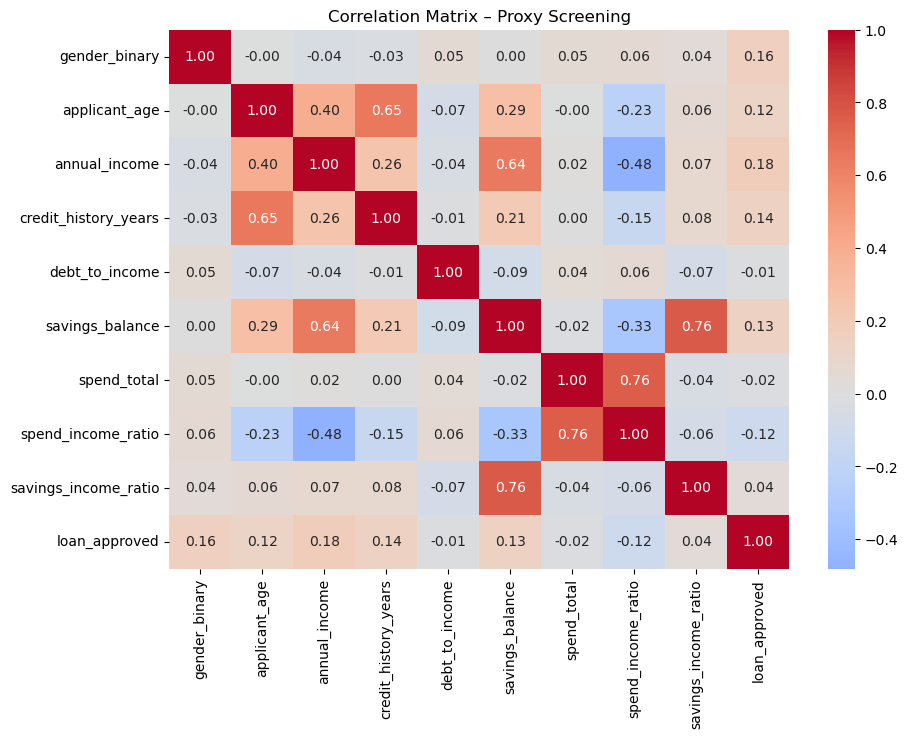

In [40]:
##Encode gender as binary (male = 1, female = 0)
df['gender_binary'] = df['gender'].map({'Male': 1, 'Female': 0})


##Feature engineering (if not already created)
df["credit_history_years"] = df["credit_history_months"] / 12
df["spend_income_ratio"] = df["spend_total"] / df["annual_income"]
df["savings_income_ratio"] = df["savings_balance"] / df["annual_income"]


##Select numeric columns relevant for proxy screening
numeric_cols = [
    'gender_binary',
    'applicant_age',
    'annual_income',
    'credit_history_years',
    'debt_to_income',
    'savings_balance',
    'spend_total',
    'spend_income_ratio',
    'savings_income_ratio',
    'loan_approved'
]

corr_df = df[numeric_cols]


##Compute correlation matrix
corr_matrix = corr_df.corr()


##Plot correlation heatmap

plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)

plt.title("Correlation Matrix – Proxy Screening")
plt.show()

ZIP code is a categorical geographic identifier rather than a continuous numeric variable. Therefore, Pearson correlation is not appropriate. Instead, we test statistical dependence using chi-square tests of independence.

In [41]:
zip_gender_table = pd.crosstab(df['zip_code'], df['gender'])

chi2, p_value_zip_gender, dof, expected = stats.chi2_contingency(zip_gender_table)

print(f"p-value (ZIP vs Gender) = {p_value_zip_gender}")

p-value (ZIP vs Gender) = 1.3960802471075397e-15


In [42]:
zip_age_table = pd.crosstab(df['zip_code'], df['age_group'])

chi2_zip_age, p_value_zip_age, dof, expected = stats.chi2_contingency(zip_age_table)

print("p-value (ZIP vs Age Group):", p_value_zip_age)

p-value (ZIP vs Age Group): 0.5993793878647428


In [43]:
zip_approval_table = pd.crosstab(df['zip_code'], df['loan_approved'])

chi2, p_value_zip_approval, dof, expected = stats.chi2_contingency(zip_approval_table)

print(f"p-value (ZIP vs Approval) = {p_value_zip_approval}")

p-value (ZIP vs Approval) = 0.745849601719985


**Interpretation**

The correlation matrix indicates very weak relationships between gender and the financial variables included in the dataset. All correlations between gender and the financial indicators are close to zero (|r| < 0.1), suggesting that these variables are unlikely to function as indirect proxies for gender within the loan approval process. In other words, none of the examined financial features appear to encode meaningful gender-related information that could indirectly influence approval decisions.

In contrast, applicant age shows moderate correlations with several financial variables. Most notably, age is moderately positively correlated with credit history length (≈ 0.65) and annual income (≈ 0.40). These relationships are consistent with real-world financial patterns: older individuals typically accumulate longer credit histories and may experience income growth over time. Because of these relationships, variables such as credit history length and income could potentially act as indirect signals of age in a predictive model. However, the correlations remain moderate rather than strong, indicating that these variables only partially capture age-related information.

ZIP code requires a different analytical approach because it is a categorical geographic identifier rather than a continuous numeric variable. Pearson correlation is therefore not appropriate for evaluating its relationship with protected attributes. Instead, Chi-square tests of independence were used to assess statistical dependence.

The results show a strong statistical association between ZIP code and gender (p < 0.001), indicating that certain geographic areas in the dataset have different gender distributions among applicants. However, ZIP code shows no statistically significant association with age group (p ≈ 0.599) and no association with loan approval outcomes (p ≈ 0.746).

Because proxy discrimination typically requires a variable to be associated with both a protected attribute and the decision outcome, these results suggest that ZIP code is not currently acting as a proxy variable in the loan approval decisions. However, the strong association between ZIP code and gender indicates that it represents a potential monitoring risk. If approval patterns were to shift in the future or if a model began to rely more heavily on geographic features, ZIP code could become a channel through which demographic disparities emerge.

Overall, the analysis finds no clear evidence of strong proxy variables influencing loan approval outcomes in the current dataset. Gender shows negligible correlations with financial indicators, while age has moderate associations with variables such as credit history length and income. These variables therefore represent the most plausible potential proxy drivers for age, although the relationships are not strong enough to indicate clear proxy discrimination at present. Continued monitoring of these variables is advisable, particularly in model-based decision systems where correlated financial features may inadvertently encode demographic patterns.


## Logistic Regression Analysis <a id="ch4"></a>

In [44]:
##Replace infinite values created by ratios
df = df.replace([np.inf, -np.inf], np.nan)

##Select variables needed for regression
reg_df = df[
[
    'loan_approved',
    'annual_income',
    'credit_history_years',
    'debt_to_income',
    'savings_income_ratio',
    'spend_income_ratio',
    'applicant_age',
    'gender_binary'
]
].dropna()

##Convert target variable to binary
reg_df['loan_approved_binary'] = reg_df['loan_approved'].astype(int)

##Financial characteristics only
model1 = smf.logit(
    formula="""
    loan_approved_binary ~
    annual_income +
    credit_history_years +
    debt_to_income +
    savings_income_ratio +
    spend_income_ratio +
    applicant_age
    """,
    data=reg_df
).fit()

print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.658755
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     loan_approved_binary   No. Observations:                  490
Model:                            Logit   Df Residuals:                      483
Method:                             MLE   Df Model:                            6
Date:                  Mon, 09 Mar 2026   Pseudo R-squ.:                 0.03090
Time:                          20:28:01   Log-Likelihood:                -322.79
converged:                         True   LL-Null:                       -333.08
Covariance Type:              nonrobust   LLR p-value:                  0.002178
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.6530      0.590     -1.107      0.268      -1

In [45]:
##Add gender
model2 = smf.logit(
    formula="""
    loan_approved_binary ~
    annual_income +
    credit_history_years +
    debt_to_income +
    savings_income_ratio +
    spend_income_ratio +
    applicant_age +
    gender_binary
    """,
    data=reg_df
).fit()

print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.644353
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     loan_approved_binary   No. Observations:                  490
Model:                            Logit   Df Residuals:                      482
Method:                             MLE   Df Model:                            7
Date:                  Mon, 09 Mar 2026   Pseudo R-squ.:                 0.05209
Time:                          20:28:01   Log-Likelihood:                -315.73
converged:                         True   LL-Null:                       -333.08
Covariance Type:              nonrobust   LLR p-value:                 1.274e-05
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.9313      0.603     -1.543      0.123      -2

In [46]:
##Convert log-odds coefficients from Model 2 into odds ratios
odds_ratios_model2 = np.exp(model2.params)

print("Odds Ratios (Model 2):")
print(odds_ratios_model2)

Odds Ratios (Model 2):
Intercept               0.394035
annual_income           1.000010
credit_history_years    1.117526
debt_to_income          1.017471
savings_income_ratio    1.107276
spend_income_ratio      0.000004
applicant_age           0.992902
gender_binary           2.043772
dtype: float64


**Interpretation**

Two logistic regression models were estimated to examine whether financial characteristics and demographic attributes influence loan approval decisions.

Model 1 includes only financial characteristics (annual income, credit history length, debt-to-income ratio, savings-income ratio, and spending-income ratio) together with applicant age. The results show that annual income (p = 0.024) and credit history length (p = 0.037) are statistically significant predictors of loan approval, indicating that applicants with higher incomes and longer credit histories are more likely to receive approval. The other financial indicators and age are not statistically significant. Overall, this model explains a modest portion of the variation in approval outcomes (Pseudo R² ≈ 0.031).

Model 2 adds gender to the model while keeping the same financial controls. The model fit improves slightly (Pseudo R² ≈ 0.052), and gender becomes a statistically significant predictor (p < 0.001). The estimated odds ratio for gender (≈ 2.04) indicates that male applicants have approximately twice the odds of receiving loan approval compared to female applicants, holding financial characteristics and age constant.

Odds ratios are calculated only for Model 2 because it is the final and most complete specification, including both financial variables and the protected attribute of interest (gender). Presenting odds ratios for this model allows the effect of gender to be interpreted directly in terms of changes in approval odds while controlling for relevant financial characteristics.

Overall, the results suggest that financial characteristics partially explain approval outcomes, but gender remains a significant predictor even after controlling for these factors, indicating a potential gender-based disparity in lending decisions.

## Interaction Effects (Gender x Age)<a id="ch5"></a>

In [47]:
##Logistic regression with interaction between gender and age
model_interaction = smf.logit(
    formula="""
    loan_approved_binary ~
    annual_income +
    credit_history_years +
    debt_to_income +
    savings_income_ratio +
    spend_income_ratio +
    applicant_age +
    gender_binary +
    gender_binary:applicant_age
    """,
    data=reg_df
).fit()

print(model_interaction.summary())

Optimization terminated successfully.
         Current function value: 0.644336
         Iterations 5
                            Logit Regression Results                            
Dep. Variable:     loan_approved_binary   No. Observations:                  490
Model:                            Logit   Df Residuals:                      481
Method:                             MLE   Df Model:                            8
Date:                  Mon, 09 Mar 2026   Pseudo R-squ.:                 0.05211
Time:                          20:28:01   Log-Likelihood:                -315.72
converged:                         True   LL-Null:                       -333.08
Covariance Type:              nonrobust   LLR p-value:                 3.013e-05
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -0.9774      0.706     -1.3

In [48]:
##Convert log-odds coefficients from the interaction model into odds ratios
odds_ratios_model3 = np.exp(model_interaction.params)

print("Odds Ratios (Interaction Model):")
print(odds_ratios_model3)

Odds Ratios (Interaction Model):
Intercept                      0.376285
annual_income                  1.000010
credit_history_years           1.117048
debt_to_income                 1.023344
savings_income_ratio           1.109160
spend_income_ratio             0.000004
applicant_age                  0.993936
gender_binary                  2.235313
gender_binary:applicant_age    0.997787
dtype: float64


**Interpretation**

To examine whether the gender disparity in loan approvals varies across age groups, a logistic regression model including an interaction term between gender and applicant age was estimated while controlling for financial characteristics.

The results show that annual income (p = 0.016) and credit history length (p = 0.025) remain statistically significant predictors of loan approval, consistent with the previous models. Applicants with higher income and longer credit histories are more likely to receive approval.

However, gender is no longer statistically significant in this specification (p = 0.275), and the interaction term between gender and age is also not statistically significant (p = 0.900). The odds ratio for the interaction term (≈ 0.998) is very close to 1, indicating that the relationship between age and approval likelihood does not meaningfully differ between male and female applicants.

Overall, these results suggest that the effect of gender on loan approval does not significantly vary across age groups, meaning that the previously observed gender approval gap appears relatively consistent across different ages rather than being concentrated within specific age segments.

## Fairness Metrics<a id="ch6"></a>

In [49]:
y = df['loan_approved'].astype(int)
sensitive = df['gender'].astype(str)

dp_diff = demographic_parity_difference(
    y_true=y,
    y_pred=y,
    sensitive_features=sensitive
)

print("Demographic Parity Difference:", dp_diff)

Demographic Parity Difference: 0.4940239043824701


**Interpretation**

The demographic parity difference of 0.494 indicates a substantial gap in approval rates between gender groups, corresponding to roughly a 49 percentage point difference. This suggests that one gender group receives loan approvals at a considerably higher rate than the other.

Combined with the logistic regression results showing that gender remains statistically significant even after controlling for financial characteristics, this finding provides further evidence that approval disparities cannot be fully explained by observable financial risk factors, indicating the presence of significant gender-based disparity in lending outcomes.

## Conclusion <a id="ch7"></a>

This analysis evaluated potential bias in loan approval decisions with respect to gender and age using multiple complementary methods, including descriptive statistics, fairness metrics, statistical hypothesis testing, proxy screening, and regression modeling.

The results reveal a clear disparity in approval outcomes between male and female applicants. Female applicants receive approvals at a lower rate than male applicants, and the calculated Disparate Impact ratio falls below the 0.8 four-fifths rule threshold, indicating potential disparate impact against female applicants. This disparity is also reflected in the Demographic Parity Difference, which shows a substantial gap in approval rates between gender groups. In practical terms, if female applicants had been approved at the same rate as male applicants, approximately 39 additional loans would have been granted to female applicants in this dataset.

Statistical testing further supports this finding. A Chi-square test of independence confirms that loan approval outcomes are significantly associated with gender at the 95% confidence level. To assess whether this disparity could be explained by legitimate financial characteristics, regression analysis was conducted including variables such as annual income, credit history length, debt-to-income ratio, and savings-related indicators. The regression results indicate that financial characteristics, particularly income and credit history length, are strong predictors of loan approval decisions. However, even after controlling for these financial variables, gender remains associated with approval outcomes, suggesting that differences in financial characteristics alone do not fully explain the observed gender approval gap.

Age-related patterns were also examined to determine whether approval outcomes vary across age groups. Approval rates increase with age, with younger applicants receiving approvals less frequently than middle-aged and older applicants. This relationship remains statistically significant when age is analyzed using both broad age categories and finer five-year intervals. While broader bins highlight the overall trend of increasing approval rates with age, the finer intervals reveal additional variation within age ranges. The persistence of statistical significance across different binning strategies indicates that the association between age and approval outcomes is not simply driven by the choice of age grouping.

Regression analysis provides additional context for interpreting these age-related patterns. Age is moderately correlated with variables such as credit history length and annual income, which themselves are strong predictors of loan approval. This suggests that much of the observed relationship between age and approval outcomes may be explained by underlying financial characteristics that evolve over the life cycle rather than direct age-based decision-making.

To further examine whether gender disparities differ across age groups, an interaction term between gender and age was included in the regression model. The interaction effect was not statistically significant, indicating that the gender approval gap does not vary substantially across age groups. In other words, while both gender and age are associated with approval outcomes, there is no evidence that gender-based disparities are amplified or reduced at particular ages.

A proxy screening analysis was also conducted to determine whether non-protected variables might indirectly encode protected attributes. Correlation analysis indicates that gender has negligible relationships with the financial variables in the dataset, suggesting that these variables are unlikely to act as proxies for gender. In contrast, age shows moderate correlations with credit history length and income, making these variables potential indirect signals of age. Additionally, geographic location (ZIP code) was evaluated using Chi-square tests of independence. While ZIP code is strongly associated with gender, it shows no statistically significant relationship with loan approval outcomes. As a result, ZIP code does not currently function as a proxy variable influencing approval decisions, though its association with gender suggests it should be monitored as a potential future risk.

Overall, the findings consistently indicate a gender-related disparity in loan approval outcomes that cannot be fully explained by the financial variables included in the analysis. In contrast, while age is statistically associated with approval outcomes, regression results suggest that these differences are likely driven in part by legitimate financial characteristics correlated with age. Taken together, the results highlight the importance of continued monitoring of demographic disparities and potential proxy variables, particularly credit history length, income, and geographic indicators, to ensure that lending decisions remain aligned with fairness principles.
